## Introducción

En estos ejercicios vamos a trabajar con  datasets que representan el conjunto de personajes de Marvel en sus cómics con características de cada uno de ellos.

Las columnas del dataframe significan lo siguiente:

1. `page_id`: Identificador único de la página del personaje dentro de la wikia.
2. `name`: Nombre del personaje.
3. `urlslug`: URL única dentro de la wikia que lleva a la página del personaje.
4. `ID`: Estado de identidad del personaje (Identidad secreta, pública, o sin identidad dual en Marvel).
5. `ALIGN`: Alineación del personaje (Bueno, Malo o Neutral).
6. `EYE`: Color de ojos del personaje.
7. `HAIR`: Color de cabello del personaje.
8. `SEX`: Sexo del personaje (e.g. Masculino, Femenino, etc.).
9. `GSM`: Indica si el personaje pertenece a una minoría de género o sexual (e.g. Homosexual, Bisexual).
10. `ALIVE`: Indica si el personaje está vivo o fallecido.
11. `APPEARANCES`: Número de apariciones del personaje en cómics (al 2 de septiembre de 2014; el número puede estar desactualizado).
12. `FIRST APPEARANCE`: Mes y año de la primera aparición del personaje en un cómic, si está disponible.
13. `YEAR`: Año de la primera aparición del personaje en un cómic, si está disponible.



# Parte 1: Extracción de Datos

Concatena todas las fuentes en un solo Dataset , añade para cada fuente una columna , que indique el origen, a fin de que cuando se concatenen poder tener trazabilidad sobre el origen de donde vino el dato. Para MongoDB usa Mongo Compass


In [26]:
import pandas as pd
import numpy as np
import json
import sqlite3
import re
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [27]:
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
sns.set_theme(style='whitegrid')

In [28]:
C = ['page_id', 'name', 'urlslug', 'ID', 'ALIGN', 'EYE', 'HAIR','SEX', 'GSM', 'ALIVE', 'APPEARANCES', 'FIRST APPEARANCE', 'YEAR']

# ------------------------- TXT--------------------------------
df_txt = pd.read_csv('fuentes marvel/marvel_characters.txt', sep=';')
df_txt.columns = C
df_txt['source'] = 'TXT'
print(f'TXT {df_txt.shape[0]:,} filas')

#-------------------------- XLSX -------------------------------
df_xlsx = pd.read_excel('fuentes marvel/marvel_characters.xlsx')
df_xlsx.rename(columns={'Year': 'YEAR'}, inplace=True)
df_xlsx = df_xlsx[C]
df_xlsx['source'] = 'XLSX'
print(f'XLSX {df_xlsx.shape[0]:,} filas')

# -------------------------------- JSON API----------------------------
with open('fuentes marvel/marvel_api_response.json', encoding='utf-8') as f:
    api_data = json.load(f)
df_api = pd.DataFrame(api_data['data'])
df_api.rename(columns={'Year': 'YEAR'}, inplace=True)
df_api = df_api[C]
df_api['source'] = 'API'
print(f'API {df_api.shape[0]:,} filas')

#------------------------------MongoDB ---------------------------------------
with open('fuentes marvel/marvel_mongodb.json', encoding='utf-8') as f:
    mongo_data = json.load(f)
df_mongo = pd.DataFrame(mongo_data)
df_mongo.rename(columns={'Year': 'YEAR'}, inplace=True)
df_mongo = df_mongo[C]
df_mongo['source'] = 'MongoDB'
print(f'MongoDB {df_mongo.shape[0]:,} filas')

# ----------------------------SQLite ---------------------------------
conn_sqlite = sqlite3.connect('fuentes marvel/marvel_sqlite.db')
df_sqlite = pd.read_sql('SELECT * FROM marvel_characters', conn_sqlite)
conn_sqlite.close()
df_sqlite.rename(columns={'Year': 'YEAR'}, inplace=True)
df_sqlite = df_sqlite[C]
df_sqlite['APPEARANCES'] = pd.to_numeric(df_sqlite['APPEARANCES'], errors='coerce')
df_sqlite['YEAR']        = pd.to_numeric(df_sqlite['YEAR'],        errors='coerce')
df_sqlite['source'] = 'SQLite'
print(f'SQLite     → {df_sqlite.shape[0]:,} filas')

# ---------------------------SQLServer----------------------------

sql_content = open('fuentes marvel/marvel_sqlserver.sql', encoding='utf-8').read()
# Adaptar sintaxis SQL Server → SQLite
sql_content = re.sub(r'IF OBJECT_ID.*?;\s*\n', '', sql_content, flags=re.DOTALL)
sql_content = (sql_content
            .replace('NVARCHAR(500)', 'TEXT')
            .replace('NVARCHAR(100)', 'TEXT')
            .replace('NVARCHAR(50)',  'TEXT')
            .replace("N'", "'")
            .replace('\\"', '"'))
conn_mem = sqlite3.connect(':memory:')
for stmt in sql_content.split(';'):
    stmt = stmt.strip()
    if stmt:
        try:
            conn_mem.execute(stmt)
        except Exception:
            pass
conn_mem.commit()
df_sql = pd.read_sql('SELECT * FROM marvel_characters', conn_mem)
conn_mem.close()
df_sql.rename(columns={'FIRST_APPEARANCE': 'FIRST APPEARANCE', 'Year': 'YEAR'}, inplace=True)
df_sql = df_sql[C]
df_sql['APPEARANCES'] = pd.to_numeric(df_sql['APPEARANCES'], errors='coerce')
df_sql['YEAR']        = pd.to_numeric(df_sql['YEAR'],        errors='coerce')
df_sql['source'] = 'SQLServer'
print(f'SQL Server → {df_sql.shape[0]:,} filas')

#-------------------- CONCATENAR ----------------------------------------------

df_all = pd.concat([df_txt, df_xlsx, df_api, df_mongo, df_sqlite, df_sql], ignore_index=True)


df_all['APPEARANCES'] = pd.to_numeric(df_all['APPEARANCES'], errors='coerce')
df_all['YEAR']        = pd.to_numeric(df_all['YEAR'],        errors='coerce')

print(f'Dataset concatenados: {df_all.shape[0]:,} filas × {df_all.shape[1]} columnas')
print('Filas por fuente:')
print(df_all['source'].value_counts().to_string())
df_all.head(3)



TXT 16,376 filas
XLSX 16,376 filas
API 16,376 filas
MongoDB 16,376 filas
SQLite     → 16,376 filas
SQL Server → 16,376 filas
Dataset concatenados: 98,256 filas × 14 columnas
Filas por fuente:
source
TXT          16376
XLSX         16376
API          16376
MongoDB      16376
SQLite       16376
SQLServer    16376


,page_id,name,urlslug,ID,ALIGN,EYE,HAIR,SEX,GSM,ALIVE,APPEARANCES,FIRST APPEARANCE,YEAR,source
0,1678,Spider-Man (Peter Parker),\/Spider-Man_(Peter_Parker),Secret Identity,Good Characters,Hazel Eyes,Brown Hair,Male Characters,NaN,Living Characters,4043.0,NaN,1962.0,TXT
1,7139,Captain America (Steven Rogers),\/Captain_America_(Steven_Rogers),Public Identity,Good Characters,Blue Eyes,White Hair,Male Characters,NaN,Living Characters,3360.0,NaN,1941.0,TXT
2,64786,"Wolverine (James \""Logan\"" Howlett)",\/Wolverine_(James_%22Logan%22_Howlett),Public Identity,Neutral Characters,Blue Eyes,Black Hair,Male Characters,NaN,Living Characters,3061.0,NaN,1974.0,TXT


# Parte 2: Análisis Exploratorio y Limpieza de Datos

En esta sección el estudiante debe realizar el análisis exploratorio de datos (EDA), se detectarán outliers, se limpiará el dataset y se responderán preguntas sobre los datos.


## 2.1 EDA Inicial

Se realiza un análisis exploratorio inicial del dataset para comprender su estructura, tipos de datos, cantidad de valores nulos y estadísticas descriptivas básicas.


In [29]:
print (f'{'-'*30}Informacion de los datasets{'-'*30}')
print(f'Dimensiones : {df_all.shape[0]:,} filas × {df_all.shape[1]} columnas')
print(f'Memoria     : {df_all.memory_usage(deep=True).sum() / 1024**2:.2f} MB')

print (f'{'-'*30}Tipos de datos{'-'*30}')
print(df_all.dtypes)

print (f'{'-'*30}Valores nulos{'-'*30}')
display(df_all.describe())

nulos = df_all.isnull().sum()
pct   = (nulos / len(df_all) * 100).round(2)
nulos_df = pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': pct})
display(nulos_df[nulos_df['Nulos'] > 0])

print(f'{'-'*30}Primeras 5 filas{'-'*30} ')
display(df_all.head())


------------------------------Informacion de los datasets------------------------------
Dimensiones : 98,256 filas × 14 columnas
Memoria     : 62.46 MB
------------------------------Tipos de datos------------------------------
page_id               int64
name                 object
urlslug              object
ID                   object
ALIGN                object
EYE                  object
HAIR                 object
SEX                  object
GSM                  object
ALIVE                object
APPEARANCES         float64
FIRST APPEARANCE     object
YEAR                float64
source               object
dtype: object
------------------------------Valores nulos------------------------------


,page_id,APPEARANCES,YEAR
count,98256.000000,91680.000000,93366.000000
mean,300232.082377,17.033377,1984.951803
std,253453.954271,96.370331,19.663045
min,1025.000000,1.000000,1939.000000
25%,28309.500000,1.000000,1974.000000
50%,282578.000000,3.000000,1990.000000
75%,509077.000000,8.000000,2000.000000
max,755278.000000,4043.000000,2013.000000


,Nulos,Porcentaje (%)
ID,11310,11.51
ALIGN,8436,8.59
EYE,29301,29.82
HAIR,12792,13.02
SEX,2562,2.61
GSM,48858,49.73
ALIVE,9,0.01
APPEARANCES,6576,6.69
FIRST APPEARANCE,18006,18.33
YEAR,4890,4.98


------------------------------Primeras 5 filas------------------------------ 


,page_id,name,urlslug,ID,ALIGN,EYE,HAIR,SEX,GSM,ALIVE,APPEARANCES,FIRST APPEARANCE,YEAR,source
0,1678,Spider-Man (Peter Parker),\/Spider-Man_(Peter_Parker),Secret Identity,Good Characters,Hazel Eyes,Brown Hair,Male Characters,NaN,Living Characters,4043.0,NaN,1962.0,TXT
1,7139,Captain America (Steven Rogers),\/Captain_America_(Steven_Rogers),Public Identity,Good Characters,Blue Eyes,White Hair,Male Characters,NaN,Living Characters,3360.0,NaN,1941.0,TXT
2,64786,"Wolverine (James \""Logan\"" Howlett)",\/Wolverine_(James_%22Logan%22_Howlett),Public Identity,Neutral Characters,Blue Eyes,Black Hair,Male Characters,NaN,Living Characters,3061.0,NaN,1974.0,TXT
3,1868,"Iron Man (Anthony \""Tony\"" Stark)",\/Iron_Man_(Anthony_%22Tony%22_Stark),Public Identity,Good Characters,Blue Eyes,Black Hair,Male Characters,NaN,Living Characters,2961.0,NaN,1963.0,TXT
4,2460,Thor (Thor Odinson),\/Thor_(Thor_Odinson),No Dual Identity,Good Characters,Blue Eyes,Blond Hair,Male Characters,NaN,Living Characters,2258.0,NaN,1950.0,TXT


### Gráfico 1: Distribución por Alineación (ALIGN)

Visualiza cuántos personajes hay de cada tipo de alineación (Bueno, Malo, Neutral, etc.).


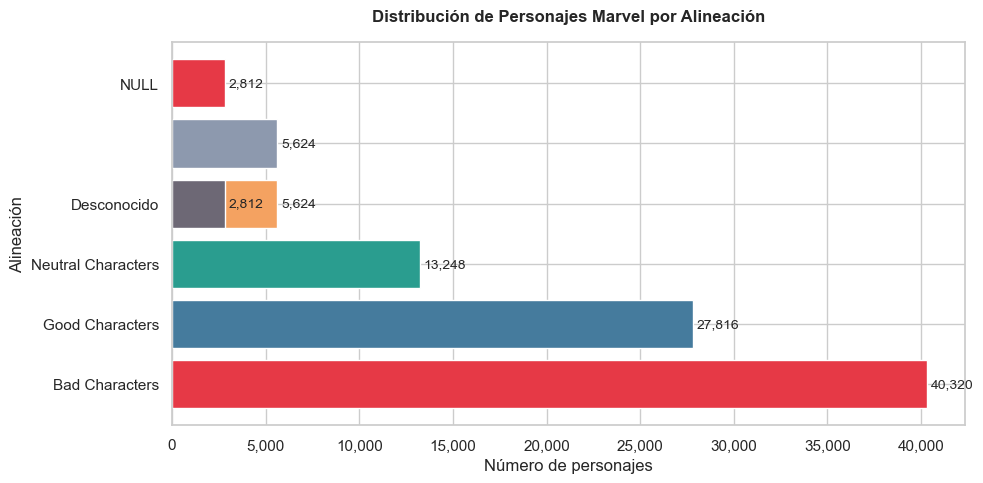

In [30]:

align_counts = df_all['ALIGN'].value_counts(dropna=False).reset_index()
align_counts.columns = ['ALIGN', 'count']
align_counts['ALIGN'] = align_counts['ALIGN'].fillna('Desconocido')

colores = ['#e63946', '#457b9d', '#2a9d8f', '#f4a261', '#8d99ae', '#6d6875']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(align_counts['ALIGN'], align_counts['count'],
               color=colores[:len(align_counts)], edgecolor='white')

for bar in bars:
    w = bar.get_width()
    ax.text(w + 200, bar.get_y() + bar.get_height() / 2, f'{w:,.0f}', va='center', fontsize=10)

ax.set_title('Distribución de Personajes Marvel por Alineación', fontweight='bold', pad=15)
ax.set_xlabel('Número de personajes')
ax.set_ylabel('Alineación')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()


Los personajes Buenos son los mas numerosos del universo Marvel, seguidos de los personajes Malos y Neutrales, la porcion considerable no presenta una alineacion definida reflejando la riqueza de personajes secundarios

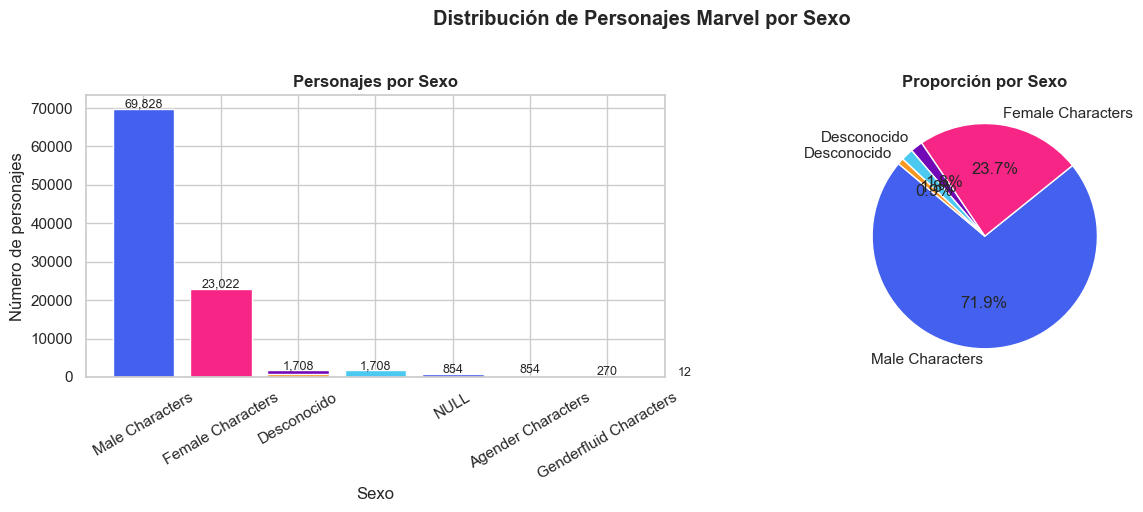

In [31]:
sex_counts = df_all['SEX'].value_counts(dropna=False).reset_index()
sex_counts.columns = ['SEX', 'count']
sex_counts['SEX'] = sex_counts['SEX'].fillna('Desconocido')

colores_sex = ['#4361ee', '#f72585', '#7209b7', '#4cc9f0', '#f8961e']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# ---------------------------------------Grafico de barras----------------------------------------
ax1.bar(sex_counts['SEX'], sex_counts['count'],
        color=colores_sex[:len(sex_counts)], edgecolor='white')
for i, (val, cnt) in enumerate(zip(sex_counts['SEX'], sex_counts['count'])):
    ax1.text(i, cnt + 300, f'{cnt:,}', ha='center', fontsize=9)
ax1.set_title('Personajes por Sexo', fontweight='bold')
ax1.set_xlabel('Sexo')
ax1.set_ylabel('Número de personajes')
ax1.tick_params(axis='x', rotation=30)

# ---------------------------------------Grafico de pastel-------------------------------------------

top5 = sex_counts.head(5)
ax2.pie(top5['count'], labels=top5['SEX'], autopct='%1.1f%%',
        colors=colores_sex[:len(top5)], startangle=140)
ax2.set_title('Proporción por Sexo', fontweight='bold')

plt.suptitle('Distribución de Personajes Marvel por Sexo', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


Los personajes masclinos dominan el universo de Marvel, representando aproximadamente el 69% del total, los personajes femeninos constituyen alreedor del 25%, reflejando una brecha de genero en la industria del comic que a ido decreciendo gradualmente

## 2.2 Cálculo de Outliers




In [32]:

q1  = df_all['APPEARANCES'].quantile(0.25)
q3  = df_all['APPEARANCES'].quantile(0.75)
iqr = q3 - q1
lim_inf = q1 - 1.5 * iqr
lim_sup = q3 + 1.5 * iqr

outliers = df_all[(df_all['APPEARANCES'] < lim_inf) | (df_all['APPEARANCES'] > lim_sup)]

print('Cálculo de Outliers ')
print(f'  Q1         : {q1:.0f}')
print(f'  Q3         : {q3:.0f}')
print(f'  IQR        : {iqr:.0f}')
print(f'  Límite inf : {lim_inf:.0f}')
print(f'  Límite sup : {lim_sup:.0f}')
print(f'  Total outliers detectados: {len(outliers):,}')

print('\nTop 10 personajes con mas apariciones :')
display(outliers[['name', 'APPEARANCES', 'ALIGN', 'source']]
        .sort_values('APPEARANCES', ascending=False)
        .drop_duplicates('name')
        .head(10))


Cálculo de Outliers 
  Q1         : 1
  Q3         : 8
  IQR        : 7
  Límite inf : -10
  Límite sup : 18
  Total outliers detectados: 11,628

Top 10 personajes con mas apariciones :


,name,APPEARANCES,ALIGN,source
0,Spider-Man (Peter Parker),4043.0,Good Characters,TXT
16377,Captain America (Steven Rogers),3360.0,Good Characters,XLSX
16378,"Wolverine (James \""Logan\"" Howlett)",3061.0,Neutral Characters,XLSX
81882,"Wolverine (James ""Logan"" Howlett)",3061.0,Neutral Characters,SQLServer
3,"Iron Man (Anthony \""Tony\"" Stark)",2961.0,Good Characters,TXT
81883,"Iron Man (Anthony ""Tony"" Stark)",2961.0,Good Characters,SQLServer
16380,Thor (Thor Odinson),2258.0,Good Characters,XLSX
49133,Benjamin Grimm (Earth-616),2255.0,Good Characters,MongoDB
81886,Reed Richards (Earth-616),2072.0,Good Characters,SQLServer
32759,Hulk (Robert Bruce Banner),2017.0,Good Characters,API


### Gráfico 3: Diagrama BoxPlot 

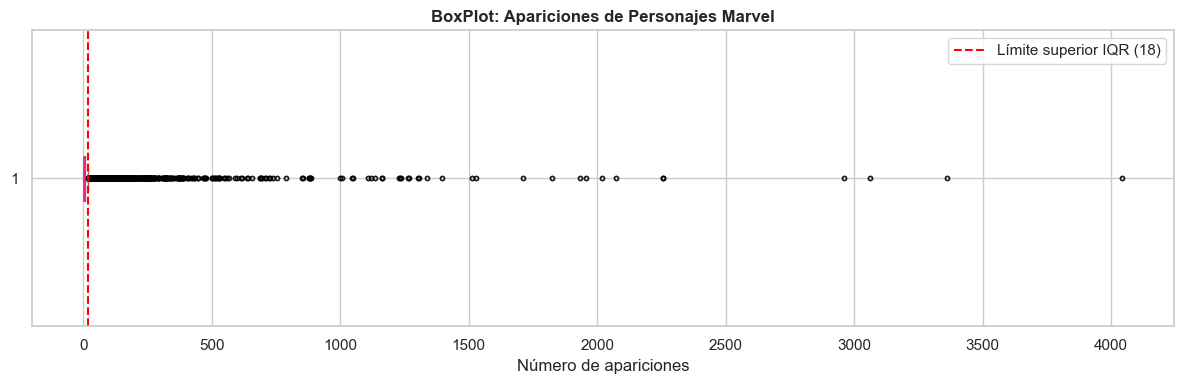

In [33]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.boxplot(df_all['APPEARANCES'].dropna(), vert=False, patch_artist=True,
        boxprops=dict(facecolor='#4361ee', alpha=0.6),
        medianprops=dict(color='#f72585', linewidth=2),
        whiskerprops=dict(color='gray'),
        capprops=dict(color='gray'),
        flierprops=dict(marker='o', color='#f72585', alpha=0.3, markersize=3))

ax.axvline(lim_sup, color='red', linestyle='--', label=f'Límite superior IQR ({lim_sup:.0f})')
ax.set_title('BoxPlot: Apariciones de Personajes Marvel', fontweight='bold')
ax.set_xlabel('Número de apariciones')
ax.legend()
plt.tight_layout()
plt.show()

en la grafica se muestra la mayoria de personajes tiene muy pocas apariciones, mientras que los superheroes mas conocidos constituyen outliders con miles de apariciones

### Gráfico 4: Diagrama de densidad de núcleo (KDE)

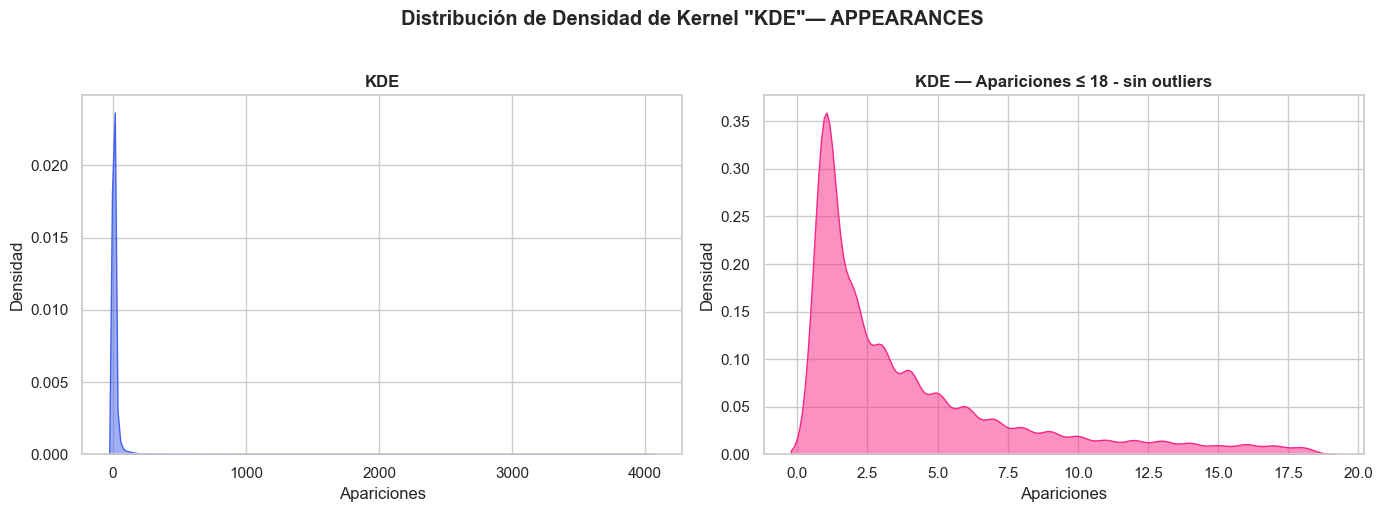

In [34]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))


data_kde = df_all['APPEARANCES'].dropna()
sns.kdeplot(data_kde, ax=ax1, fill=True, color='#4361ee', alpha=0.5)
ax1.set_title('KDE', fontweight='bold')
ax1.set_xlabel('Apariciones')
ax1.set_ylabel('Densidad')


data_sin_outliers = data_kde[data_kde <= lim_sup]
sns.kdeplot(data_sin_outliers, ax=ax2, fill=True, color='#f72585', alpha=0.5)
ax2.set_title(f'KDE — Apariciones ≤ {lim_sup:.0f} - sin outliers', fontweight='bold')
ax2.set_xlabel('Apariciones')
ax2.set_ylabel('Densidad')

plt.suptitle('Distribución de Densidad de Kernel "KDE"— APPEARANCES', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

En la el grafico de color rosado veerifica el fuerte sesgo la densiddad se consentra cerca de 0 apariciones, al eliminar todos los outliders, se visualiza que la mayoria de personajes aparecen menos desde 10.0 en adelante.

## 2.3 Limpieza de Datos

Se debe aplicar los siguientes pasos de limpieza:

- **Eliminar duplicados** exactos del dataset.
- **Imputar valores nulos** en columnas categóricas con `'Desconocido'`.
- **Imputar valores nulos** en columnas numéricas con la **mediana** de la columna.


In [35]:
print(f'{'-'*25}Antes de la Limpieza{'-'*25}')

print(f'Filas totales    : {len(df_all):,}')
print(f'Duplicados exactos: {df_all.duplicated().sum():,}')
print(f'Valores nulos    : {df_all.isnull().sum().sum():,}')

# 1. Eliminar duplicados
df_clean = df_all.drop_duplicates()
print(f'{'-'*25}Duplicados eliminados{'-'*25}')
print(f'Eliminados: {len(df_all) - len(df_clean):,}')

# 2. Imputar valores nulos 

cols_cat = df_clean.select_dtypes(include='object').columns.tolist()
for col in cols_cat:
    nulos_antes = df_clean[col].isnull().sum()
    df_clean[col] = df_clean[col].fillna('Desconocido')
    if nulos_antes:
        print(f'  Columna [{col}]: {nulos_antes:,} nulos imputados con Desconocido')

for col in cols_cat:
    df_clean[col] = df_clean[col].replace({
        '': 'Desconocido', 
        'NULL': 'Desconocido', 
        'nan': 'Desconocido'
        })

#3. Imputar valores nulos en columnas numericas 
cols_num = df_clean.select_dtypes(include='number').columns.tolist()
for col in cols_num:
    mediana = df_clean[col].median()
    nulos_antes = df_clean[col].isnull().sum()
    df_clean[col] = df_clean[col].fillna(mediana)
    if nulos_antes:
        print(f'  Columna [{col}]: {nulos_antes:,} nulos imputados con mediana ({mediana:.1f})')


print()
print(f'  Filas totales  : {len(df_clean):,}')
print(f'  Valores nulos  : {df_clean.isnull().sum().sum()}')
display(df_clean.head(3))



-------------------------Antes de la Limpieza-------------------------
Filas totales    : 98,256
Duplicados exactos: 0
Valores nulos    : 142,740
-------------------------Duplicados eliminados-------------------------
Eliminados: 0
  Columna [ID]: 11,310 nulos imputados con Desconocido
  Columna [ALIGN]: 8,436 nulos imputados con Desconocido
  Columna [EYE]: 29,301 nulos imputados con Desconocido
  Columna [HAIR]: 12,792 nulos imputados con Desconocido
  Columna [SEX]: 2,562 nulos imputados con Desconocido
  Columna [GSM]: 48,858 nulos imputados con Desconocido
  Columna [ALIVE]: 9 nulos imputados con Desconocido
  Columna [FIRST APPEARANCE]: 18,006 nulos imputados con Desconocido
  Columna [APPEARANCES]: 6,576 nulos imputados con mediana (3.0)
  Columna [YEAR]: 4,890 nulos imputados con mediana (1990.0)

  Filas totales  : 98,256
  Valores nulos  : 0


,page_id,name,urlslug,ID,ALIGN,EYE,HAIR,SEX,GSM,ALIVE,APPEARANCES,FIRST APPEARANCE,YEAR,source
0,1678,Spider-Man (Peter Parker),\/Spider-Man_(Peter_Parker),Secret Identity,Good Characters,Hazel Eyes,Brown Hair,Male Characters,Desconocido,Living Characters,4043.0,Desconocido,1962.0,TXT
1,7139,Captain America (Steven Rogers),\/Captain_America_(Steven_Rogers),Public Identity,Good Characters,Blue Eyes,White Hair,Male Characters,Desconocido,Living Characters,3360.0,Desconocido,1941.0,TXT
2,64786,"Wolverine (James \""Logan\"" Howlett)",\/Wolverine_(James_%22Logan%22_Howlett),Public Identity,Neutral Characters,Blue Eyes,Black Hair,Male Characters,Desconocido,Living Characters,3061.0,Desconocido,1974.0,TXT


Consulta y responde, para imputar valores nulos en columnas numericas, cuando es recomendable hacerlo con la media, la mediana, la moda o talvez existen alguna otra técnica?. Responde para cada caso cuando es recomendable

- Media: es la distribución simétrica normal sin outliers, es sensible a valores extremos  
- Mediana: distribución sesgada o con outliers como APPEARANCES Más robusta que la media  
- Moda: variables numéricas discretas o con pocos valores únicos ejemplo número de hijos
- Imputación por regresión: cuando existe correlación entre la variable con nulos y otras columnas del dataset, se entrena un modelo para predecir el valor faltante  
- KNN K vecinos más cercanos: cuando los datos tienen estructura espacial o de similitud, los valores se imputan usando los k registros más similares  
- MICE o imputación múltiple: cuando el porcentaje de nulos es alto y se necesita preservar la distribución original Genera múltiples imputaciones y las combina  
Valor constante: cuando la ausencia de dato tiene un significado concreto ejemplo 0 apariciones igual a sin apariciones



## 2.4 EDA PROFUNDO

Ejercicio 1. Comparación de personajes por década de creación  
Crea una columna de décadas a partir de YEAR.  
Cuenta cuántos personajes fueron creados en cada década.  
Identifica las décadas con mayor número de personajes.  
Realiza una breve interpretación de la evolución de creación de personajes a lo largo del tiempo.  



Personajes únicos creados por década:
  1930s:    69  ███
  1940s: 1,441  ████████████████████████████████████████████████████████████████████████
  1950s:   302  ███████████████
  1960s: 1,306  █████████████████████████████████████████████████████████████████
  1970s: 2,234  ███████████████████████████████████████████████████████████████████████████████████████████████████████████████
  1980s: 2,425  █████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  1990s: 4,472  ███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  2000s: 3,086  ██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  2010s: 1,041  ██████████████████████████████████████████████

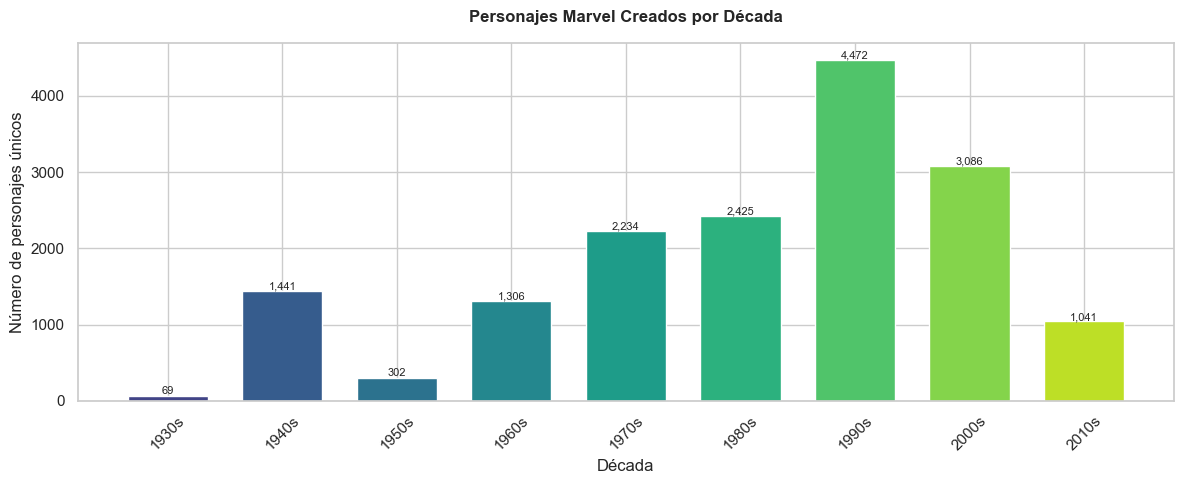

In [36]:
df_clean['DECADE'] = (df_clean['YEAR'] // 10 * 10).astype(int)
df_unico = df_clean.drop_duplicates(subset=['page_id'])
decadas = df_unico['DECADE'].value_counts().sort_index()

print('Personajes únicos creados por década:')
for dec, cnt in decadas.items():
    barra = '█' * (cnt // 20)
    print(f'  {dec}s: {cnt:5,}  {barra}')

print(f'\nDécadas con mayor creación:')
top3 = decadas.nlargest(3)
for dec, cnt in top3.items():
    print(f'  {dec}s → {cnt:,} personajes')

fig, ax = plt.subplots(figsize=(12, 5))
colores_dec = plt.cm.viridis(np.linspace(0.2, 0.9, len(decadas)))
bars = ax.bar(decadas.index.astype(str) + 's', decadas.values,
              color=colores_dec, edgecolor='white', width=0.7)
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 20,
            f'{h:,}', ha='center', fontsize=8, rotation=0)
ax.set_title('Personajes Marvel Creados por Década', fontweight='bold', pad=15)
ax.set_xlabel('Década')
ax.set_ylabel('Número de personajes únicos')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()




En la creacion de personajes Marvel crecio notablemente desde la decada de 1960, el pico se registra en el año de 1990 un periodo donde destacaba las series, apartir del año 2000 hay una desaceleracion, posiblemente consolido sus creaciones principales, antes de crear nuevos personajes

## 2.5 Preguntas

Responde las siguientes preguntas utilizando el dataset limpio:

1. ¿Cuántos personajes están vivos y cuántos han fallecido?
2. ¿Cuál es el color de cabello más común entre los personajes buenos?
3. ¿Qué porcentaje de personajes tiene identidad secreta?
4. ¿Cuál fue el año en que se crearon más personajes?


In [37]:
df_q = df_clean.drop_duplicates(subset=['page_id'])

alive = df_q['ALIVE'].value_counts()
print(alive.to_string())
vivos    = df_q[df_q['ALIVE'] == 'Living Characters'].shape[0]
fallecidos = df_q[df_q['ALIVE'] == 'Deceased Characters'].shape[0]
print(f'\nVivos    : {vivos:,} - {vivos/len(df_q)*100:.1f}%')
print(f'Fallecidos: {fallecidos:,} - {fallecidos/len(df_q)*100:.1f}%')


ALIVE
Living Characters      12608
Deceased Characters     3765
Desconocido                3

Vivos    : 12,608 - 77.0%
Fallecidos: 3,765 - 23.0%


In [38]:
buenos = df_q[df_q['ALIGN'] == 'Good Characters']
cabello_comun = buenos['HAIR'].value_counts().head(5)
print(cabello_comun.to_string())
print(f'\nEl color de cabello más común en personajes buenos es: "{cabello_comun.index[0]}"')
print(f'Con {cabello_comun.iloc[0]:,} personajes')

HAIR
Black Hair     1146
Desconocido     945
Brown Hair      776
Blond Hair      628
White Hair      269

El color de cabello más común en personajes buenos es: "Black Hair"
Con 1,146 personajes


In [39]:
id_secreta = df_q[df_q['ID'] == 'Secret Identity'].shape[0]
total = len(df_q)
pct_secreta = id_secreta / total * 100
print(df_q['ID'].value_counts().to_string())
print(f'\nPersonajes con identidad secreta: {id_secreta:,} de {total:,}')
print(f'Porcentaje: {pct_secreta:.2f}%')

ID
Secret Identity                  6275
Public Identity                  4528
Desconocido                      3770
No Dual Identity                 1788
Known to Authorities Identity      15

Personajes con identidad secreta: 6,275 de 16,376
Porcentaje: 38.32%


In [40]:
por_anno = df_q['YEAR'].value_counts().sort_values(ascending=False)
mejor_anno = int(por_anno.index[0])
print(f'\ngAño con más personajes creados: {mejor_anno}')
print(f'Personajes creados ese año: {por_anno.iloc[0]:,}')
print('\nTop 5 años:')
print(por_anno.head(5).to_string())


gAño con más personajes creados: 1990
Personajes creados ese año: 1,172

Top 5 años:
YEAR
1990.0    1172
1993.0     554
1994.0     485
1992.0     455
2006.0     381


# Parte 3: Visualización de Datos(COMUNICACION DE INFORMACIÓN)


### EJERCICIO 1. Gráfico de tendencia: Evolución de la cantidad de personajes creados por año

- Analiza la cantidad de personajes creados cada año (YEAR).
- Crea un gráfico de línea que muestre la evolución del número de personajes creados a lo largo del tiempo.
- Realiza una interpretación del gráfico


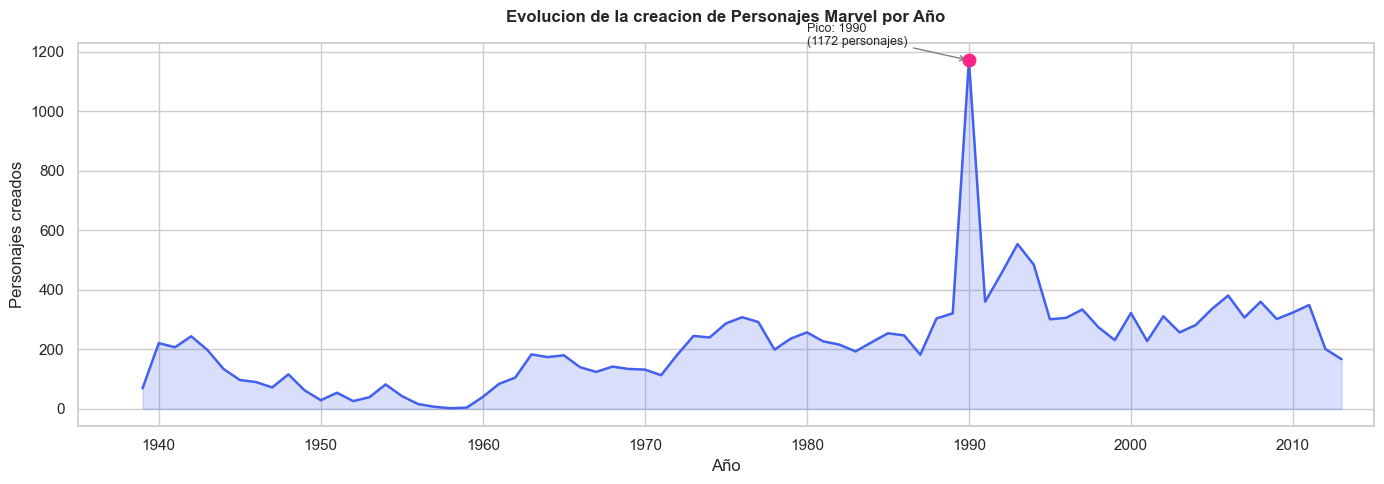

In [41]:
por_anno_serie = (df_q.groupby('YEAR').size().reset_index(name='count').sort_values('YEAR'))

# Filtrar años 
por_anno_serie = por_anno_serie[(por_anno_serie['YEAR'] >= 1935) & (por_anno_serie['YEAR'] <= 2015)]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(por_anno_serie['YEAR'], por_anno_serie['count'],
        color='#4361ee', linewidth=1.8, zorder=2)
ax.fill_between(por_anno_serie['YEAR'], por_anno_serie['count'],
                alpha=0.2, color='#4361ee')

# Marcar el año 
pico = por_anno_serie.loc[por_anno_serie['count'].idxmax()]
ax.scatter(pico['YEAR'], pico['count'], color='#f72585', zorder=5, s=80)
ax.annotate(f"Pico: {int(pico['YEAR'])}\n({int(pico['count'])} personajes)",
            xy=(pico['YEAR'], pico['count']),
            xytext=(pico['YEAR']-10, pico['count']+50),
            arrowprops=dict(arrowstyle='->', color='gray'),
            fontsize=9)

ax.set_title('Evolucion de la creacion de Personajes Marvel por Año', fontweight='bold', pad=15)
ax.set_xlabel('Año')
ax.set_ylabel('Personajes creados')
ax.set_xlim(1935, 2015)
plt.tight_layout()
plt.show()

En el grafico muestra:  
El pico de 1990 con 1172 personajes creados en un solo año por encima de cualquier otro periodo correspondiente al boom especulativo del comic donde Marvel lanzo masivamente, nuevos titulos variantes y personajes para atraer coleccionistas

Antes de ese pico la creacion es relativamente estable entre 100 y 250 personajes por año desde 1940 hasta 1980 sin un crecimiento gradual

Tras el pico de 1990 hay una caida pero la produccion se mantiene entre 200 y 600 personajes anuales durante el año 2000 muestra que Marvel mantuvo la creacion activa aunque sin volver a alcanzar el nivel de 1990

### EJERCICIO 2. Mapa de calor: Relación entre alineación y estado vivo/fallecido

- Analiza la relación entre la alineación del personaje (ALIGN) y su estado (ALIVE).
- Muestra un mapa de calor que cuente cuántos personajes de cada tipo (Bueno, Malo, Neutral) están vivos o fallecidos.
- Saca una conclusión del gráfico.


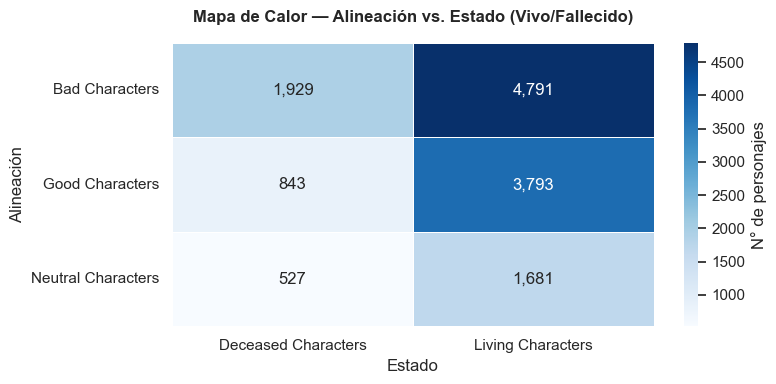

In [42]:
align_alive = df_q[
    df_q['ALIGN'].isin(['Good Characters', 'Bad Characters', 'Neutral Characters']) &
    df_q['ALIVE'].isin(['Living Characters', 'Deceased Characters'])
]

pivot = pd.crosstab(align_alive['ALIGN'], align_alive['ALIVE'])

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(pivot, annot=True, fmt=',', cmap='Blues', linewidths=0.5,
            linecolor='white', ax=ax, cbar_kws={'label': 'N° de personajes'})
ax.set_title('Mapa de Calor — Alineación vs. Estado (Vivo/Fallecido)', fontweight='bold', pad=15)
ax.set_xlabel('Estado')
ax.set_ylabel('Alineación')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

Los Bad Characters son el grupo mas numeroso en total 6720 superando a los Good Characters 4636 y Neutral Characters 2208  
  
En el estado vital los Living Characters dominan en las tres alineaciones Bad 4791 Good 3793 y Neutral 1681  

La tasa de mortalidad mas alta la tienen los personajes Buenos 843 fallecidos de 4636 totales 18.2% frente a los Malos con 1929 fallecidos de 6720 28.7% y Neutrales 527 de 2208 23.8%

En la narrativa heroica clasica los villanos mueren mas en terminos absolutos pero los heroes tambien tienen una mortalidad significativa reflejando los constantes sacrificios en la narrativa 

### EJERCICIO 3. Histograma: Distribución del número de creación de personajes por décadas

- Analiza cómo se distribuyen la creación de los personas por décadas (Year).
- Crea un histograma cuantos personajes se crearon para cada década.


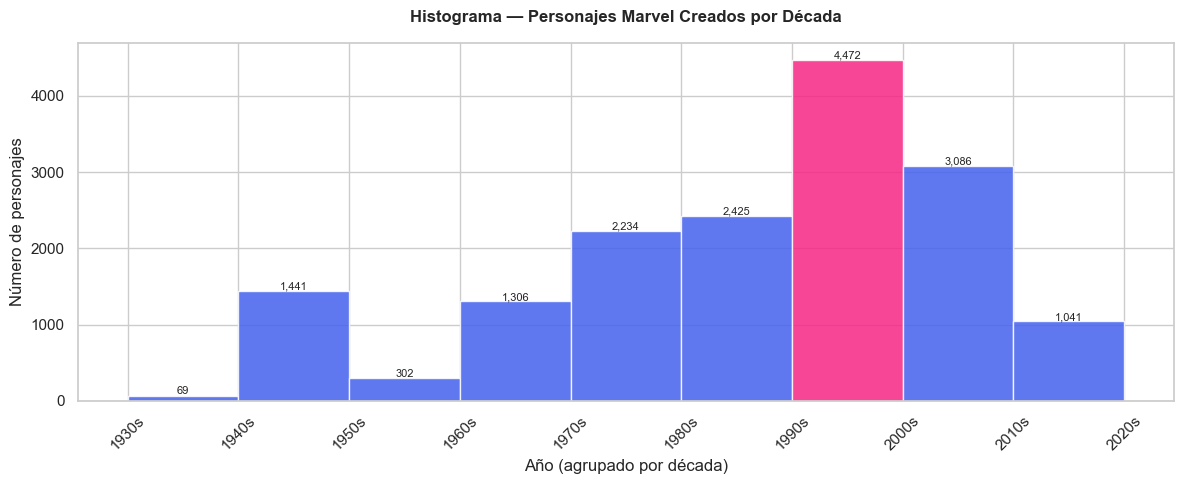

In [43]:
fig, ax = plt.subplots(figsize=(12, 5))

years_valid = df_q['YEAR'][(df_q['YEAR'] >= 1935) & (df_q['YEAR'] <= 2015)]
bins = range(1930, 2021, 10)

counts, edges, patches = ax.hist(years_valid, bins=bins, edgecolor='white',color='#4361ee', alpha=0.85)


max_idx = int(counts.argmax())
patches[max_idx].set_facecolor('#f72585')


for count, edge in zip(counts, edges):
    if count > 0:
        ax.text(edge + 5, count + 15, f'{int(count):,}', ha='center', fontsize=8)

ax.set_title('Histograma — Personajes Marvel Creados por Década', fontweight='bold', pad=15)
ax.set_xlabel('Año (agrupado por década)')
ax.set_ylabel('Número de personajes')
ax.set_xticks(list(bins))
ax.set_xticklabels([f'{b}s' for b in bins], rotation=45)
plt.tight_layout()
plt.show()

En el histograma muestra una evolucion en la creacion de personajes:  

- Marvel a lo largo de las decadas Los inicios son modestos apenas
69 personajes en los 1930s y 302 en los 1950s reflejando los primeros
años de la editorial   
- A partir de los 1940 1441 y 1960s 1305
se nota un crecimiento sostenido impulsado por la era dorada del comic  
- En la decada de 1970 -> 2234 y 1980 -> 2426 mantienen el ritmo ascendente

El pico maximo se alcanza en los 1990 con 4472 personajes en la septima barra de rosado donde Marvel expandio masivamente sus titulos

En los 2000 se mantienen altos con 3086 personajes pero los 2010 con 1041 y 2000 muestran una desaceleracion indicando que Marvel priorizo consolidar su universo antes de crear nuevos personajes.

### EJERCICIO 4. Crea 4 diagramas adicionales, diferentes a los ya usados en este deber e interpreta los resultados, cada uno deberia mostrar información relevante que considera el estudiante mostrar.

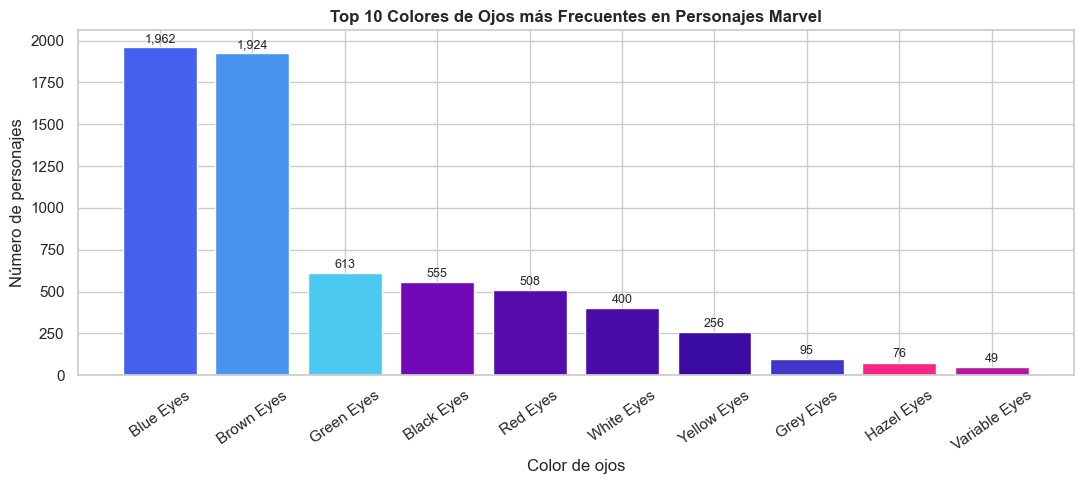

In [44]:
top_ojos = df_q[df_q['EYE'] != 'Desconocido']['EYE'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(11, 5))
paleta = ['#4361ee', '#4895ef', '#4cc9f0', '#7209b7', '#560bad',
          '#480ca8', '#3a0ca3', '#3f37c9', '#f72585', '#b5179e']


bars = ax.bar(top_ojos.index, top_ojos.values, color=paleta, edgecolor='white')
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 30,
            f'{h:,}', ha='center', fontsize=9)
    
    
ax.set_title('Top 10 Colores de Ojos más Frecuentes en Personajes Marvel', fontweight='bold')
ax.set_xlabel('Color de ojos')
ax.set_ylabel('Número de personajes')
ax.tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.show()


se visualiza:   
- Blue Eyes 1,962 y Brown Eyes 1,924 dominan ampliamente el ranking, siendo casi equivalentes entre si y muy por encima del resto  
- Green Eyes 613 ocupa el tercer lugar, seguido de Black Eyes 555 y Red Eyes 508, estos ultimos frecuentes en villanos y mutantes 
- White Eyes 400 y Yellow Eyes 256 tambien son recurrentes, asociados generalmente a personajes con poderes sobrenaturales 
- Grey Eyes 95, Hazel Eyes 76 y Variable Eyes 49 son minoritarios  
La predominancia de ojos azules y cafes refleja los rasgos fisicos usados por los autores en la era clasica del comic, mientras que colores como rojo y amarillo funcionan como recurso para identificar a los personajes no humanos o malignos


Estadisticas de apariciones por alineacion:


,media,mediana,max
ALIGN,,,
Bad Characters,8.037798,3.0,721.0
Good Characters,32.696506,4.0,4043.0
Neutral Characters,18.766304,3.0,3061.0


None


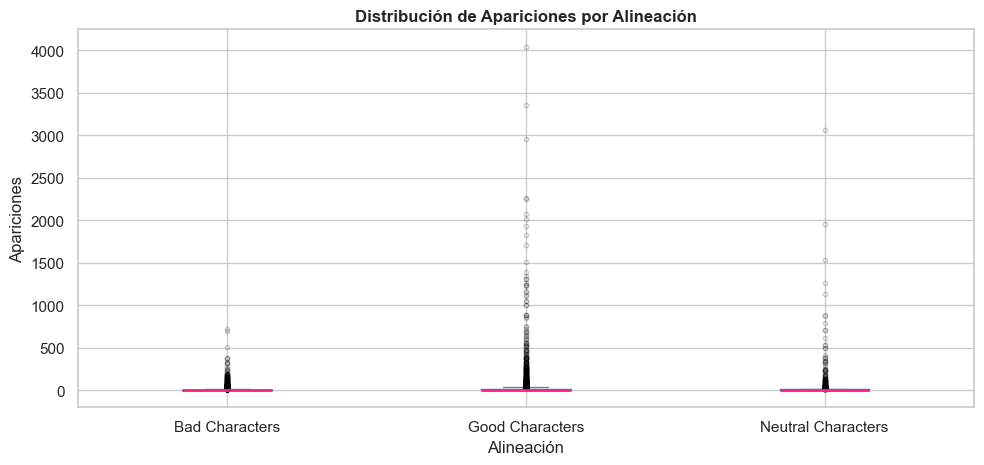

In [45]:
align_apps = (df_q[df_q['ALIGN'].isin(['Good Characters', 'Bad Characters', 'Neutral Characters'])]
            .groupby('ALIGN')['APPEARANCES']
            .describe()[['mean', '50%', 'max']]
            .rename(columns={'50%': 'mediana', 'mean': 'media'}))

print('Estadisticas de apariciones por alineacion:')
print(display(align_apps))

fig, ax = plt.subplots(figsize=(10, 5))
df_q[df_q['ALIGN'].isin(['Good Characters', 'Bad Characters', 'Neutral Characters'])].boxplot(
    column='APPEARANCES', by='ALIGN', ax=ax,
    boxprops=dict(color='#4361ee'),
    medianprops=dict(color='#f72585', linewidth=2),
    whiskerprops=dict(color='gray'),
    capprops=dict(color='gray'),
    flierprops=dict(marker='.', color='#4361ee', alpha=0.2)
)


ax.set_title('Distribución de Apariciones por Alineación', fontweight='bold')
ax.set_xlabel('Alineación')
ax.set_ylabel('Apariciones')
plt.suptitle('')
plt.tight_layout()
plt.show()


Se visualiza:  
la gran mayoria de personajes se concentra cerca de 0 apariciones, con la caja del boxplot casi pegada al eje inferior en los tres casos

Indica que independientemente de la alineacion, la mayoria de personajes Marvel son secundarios con muy poca participacion

La diferencia  se encuentra en los outliers: Good Characters alcanza el valor mas alto 3300 apariciones, correspondiente a heroes iconicos como Spider-Man o Capitan America  
Neutral Characters tambien presenta outliers altos 3000, mientras que Bad Characters tiene outliers mas moderados 600, lo que indica que los villanos
mas recurrentes aparecen considerablemente menos que los protagonistas

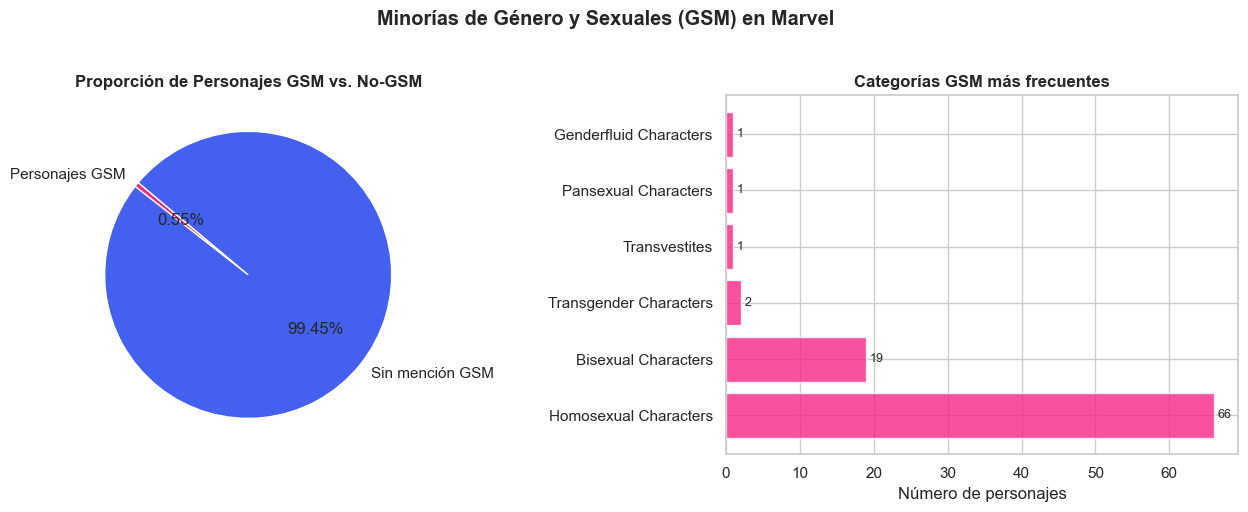

In [46]:
df_gsm = df_q.copy()
df_gsm['GSM_CLEAN'] = df_gsm['GSM'].apply(
    lambda x: x if (x not in ['Desconocido', 'NULL', '', 'nan', 'None']) else 'No GSM'
)

gsm_counts = df_gsm['GSM_CLEAN'].value_counts()
gsm_counts_top = gsm_counts[gsm_counts.index != 'No GSM']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))


gsm_prop = pd.Series({'Personajes GSM': gsm_counts_top.sum(),'Sin mención GSM': gsm_counts['No GSM']})
ax1.pie(gsm_prop, labels=gsm_prop.index, autopct='%1.2f%%',
        colors=['#f72585', '#4361ee'], startangle=140)
ax1.set_title('Proporción de Personajes GSM vs. No-GSM', fontweight='bold')


ax2.barh(gsm_counts_top.index[:8], gsm_counts_top.values[:8],
        color='#f72585', alpha=0.8, edgecolor='white')
for i, v in enumerate(gsm_counts_top.values[:8]):
    ax2.text(v + 0.5, i, f'{v}', va='center', fontsize=9)
ax2.set_title('Categorías GSM más frecuentes', fontweight='bold')
ax2.set_xlabel('Número de personajes')

plt.suptitle('Minorías de Género y Sexuales (GSM) en Marvel', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


En las dos graficas:  
El 0.55% de los personajes Marvel tiene atributos GSM explicitos,
frente al 99.45% sin mencion, evidenciando muy limitado de minorias de genero y sexuales.

Dentro de ese grupo, los Homosexual Characters son ampliamente los mas representados con 66 personajes, seguidos de los Bisexual
Characters con 19, las categorias Transgender (2), Transvestites (1),
Pansexual (1) y Genderfluid (1) tienen una presencia casi simbolica

la que se muestra que aunque ha avanzado en inclusion, concentra
su representacion GSM principalmente en personajes homosexuales,
dejando otras identidades practicamente sin visibilidad 

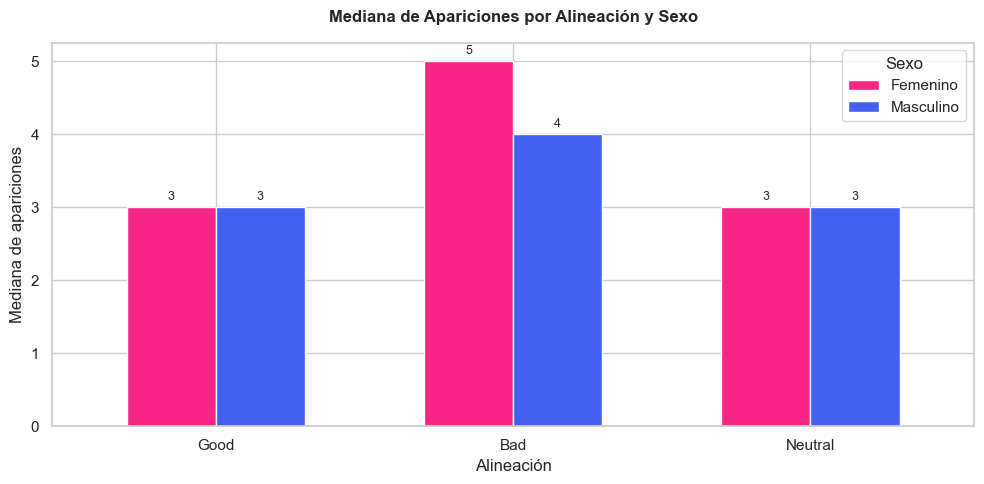

In [47]:
alineaciones = ['Good Characters', 'Bad Characters', 'Neutral Characters']
sexos = ['Male Characters', 'Female Characters']

df_pivot = (df_q[df_q['ALIGN'].isin(alineaciones) & df_q['SEX'].isin(sexos)]
            .groupby(['ALIGN', 'SEX'])['APPEARANCES']
            .median()
            .unstack())

fig, ax = plt.subplots(figsize=(10, 5))
df_pivot.plot(kind='bar', ax=ax,
              color=['#f72585', '#4361ee'], edgecolor='white',
              width=0.6)

ax.set_title('Mediana de Apariciones por Alineación y Sexo', fontweight='bold', pad=15)
ax.set_xlabel('Alineación')
ax.set_ylabel('Mediana de apariciones')
ax.set_xticklabels([l.replace(' Characters', '') for l in alineaciones], rotation=0)
ax.legend(title='Sexo', labels=['Femenino', 'Masculino'])
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3, fontsize=9)
plt.tight_layout()
plt.show()


los personajes en el caso de:  
- la mediana de apariciones es baja y uniforme en la primera interpretacion 'Good' y en la tercera 'Neutral' de categorias lo que indica que la mitad de los personajes Marvel apenas aparece en unos pocos cómics, sin importar su sexo.  
- La excepción notable son los personajes malos femeninos, que tienen la mediana más alta (5), seguidos de los malos masculinos (4).  
- Sugiere que las villanas que llegan a ser relevantes tienden a tener mayor recurrencia narrativa que las heroínas o personajes neutrales  
- En Good y Neutral, la mediana es idéntica entre ambos sexos (3)